# Лабораторная 5. Моделирование процесса $\alpha$-устойчивого движения Леви.

## 1. Определение $\alpha$-устойчивого случайного процесса Леви.

$\alpha$-устойчивым случайным процессом Леви, называется случайный процесс $L_{\alpha}(t), \alpha \in (0; 2], t \in T = [0, \inf)$, обладающий следующими свойствами:

1. $L_{\alpha}(0)=0$ п.н.;
2. $\forall 0 \le t_0 < t_1 < \dots < t_n$ СВ $L_{\alpha}(t_1) - L_{\alpha}(t_0), L_{\alpha}(t_2) - L_{\alpha}(t_1), \dots, L_{\alpha}(t_n) - L_{\alpha}(t_{n-1})$ независимы в совокупности;
3. СВ $L_{\alpha}(t) - L_{\alpha}(s), 0 \le s \le t$ имеет $\alpha$-устойчивое распределение $S_{\alpha}(\beta, \sigma(t-s)^{1/\alpha},0)$.

Этот процесс является обобщением Винеровского процесса. Процесс Леви имеет тяжёлые хвосты и скачкообразные траектории при $\alpha<2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levy_stable

## 2. Алгоритм моделирования

$T$ - конечное время, $N$ - шаг, $\sigma$ - коэффициент масштаба, $\beta$ - коэффициент асимметрии, $\Delta t = T/N$
1. Генерируем $N$ случайных величин, имеющих распределение $S_{\alpha}(\beta, \sigma(t-s)^{1/\alpha},0)$;
2. Заменяем первую случайную величину на 0;
3. Считаем кумулянтную сумму случайных величин;

И так для каждого пути.

In [2]:
def simulate_levy_process(T=1.0, N=250, n_paths=1, alpha=2.0, beta=0.0, sigma=1.0, seed=42):
    dt = T / N
    np.random.seed(seed)
    random_variables = np.array([levy_stable.rvs(alpha, beta, 0, sigma * dt ** (1 / alpha), size=N) for _ in range(n_paths)])
    random_variables[:, 0] = 0

    process = np.cumsum(random_variables, axis=1)
    time_net = np.linspace(0, T, N)
    return time_net, process

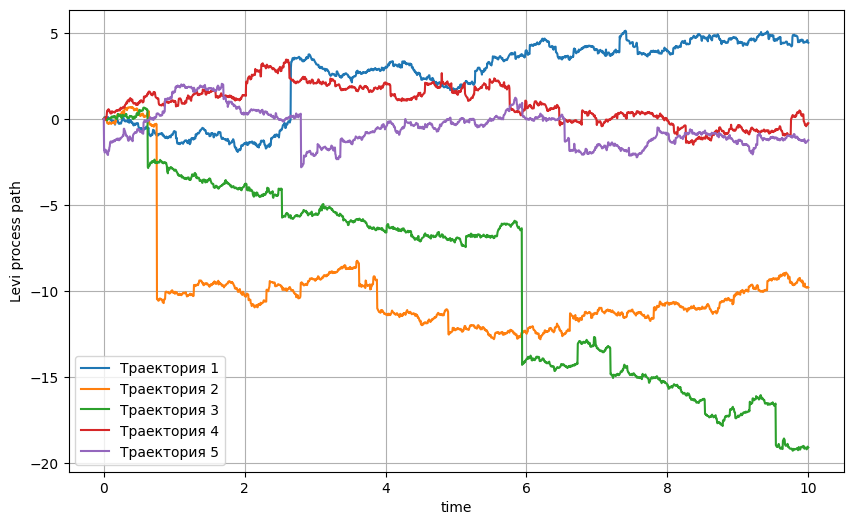

In [3]:
t, L = simulate_levy_process(T=10, N=2000, n_paths=5, seed=42, alpha=1.5, beta=0)

plt.figure(figsize=(10, 6))
for i in range(L.shape[0]):
    plt.plot(t, L[i], label=f'Траектория {i+1}')

plt.xlabel('time')
plt.ylabel('Levi process path')
plt.grid()
plt.legend()
plt.show()

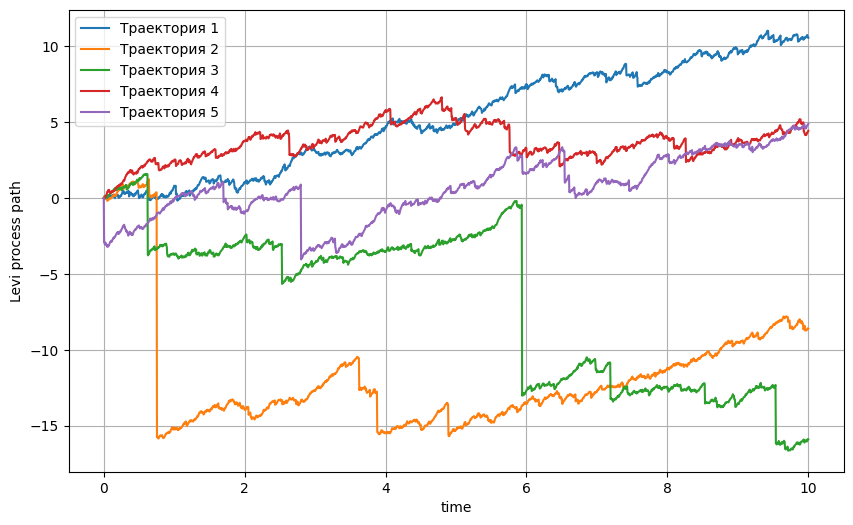

In [4]:
t, L = simulate_levy_process(T=10, N=2000, n_paths=5, seed=42, alpha=1.5, beta=-1)

plt.figure(figsize=(10, 6))
for i in range(L.shape[0]):
    plt.plot(t, L[i], label=f'Траектория {i+1}')

plt.xlabel('time')
plt.ylabel('Levi process path')
plt.grid()
plt.legend()
plt.show()

Следует отметить, что процесс начинает быстрее возрасть и медленне убывать при отрицательных $\beta$. Это происходит из-за того, что у устойчивого распределения появляется скок и случайные величины одного знака начинают генерироваться чаще, если изменить параметр $\beta$.



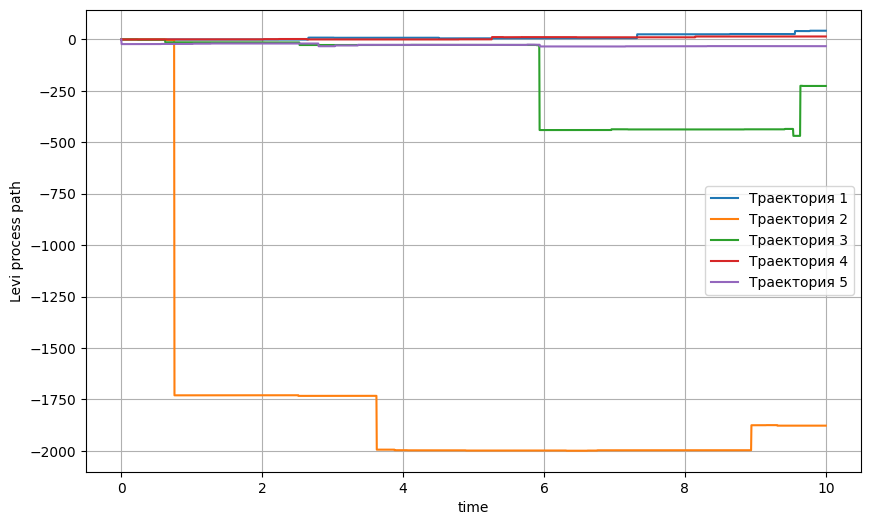

In [5]:
t, L = simulate_levy_process(T=10, N=2000, n_paths=5, seed=42, alpha=0.5, beta=0)

plt.figure(figsize=(10, 6))
for i in range(L.shape[0]):
    plt.plot(t, L[i], label=f'Траектория {i+1}')

plt.xlabel('time')
plt.ylabel('Levi process path')
plt.grid()
plt.legend()
plt.show()

В свою очередь, при уменьшении $\alpha$ распределение становится всё менее стабильным и скачки становятся очень большими. Это объяснеятся тяжёлыми хвостами устойчивого распределения. Между скачками мы имеем практически горизонтальные участки. Это объяснется тем, что параметр масштаба $(\Delta t)^{1/\alpha}$ становится очень мал при малых $\alpha$. Математическое ожидание перестаёт существовать (равно бесконечности).

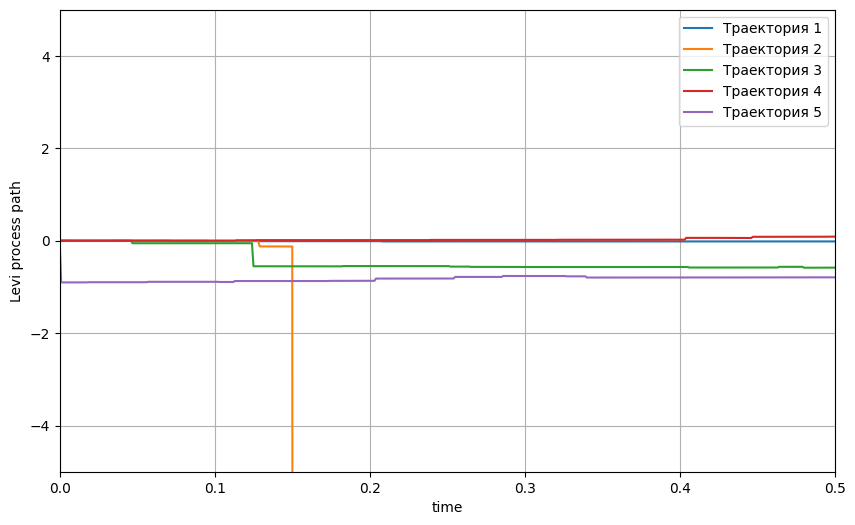

In [9]:
t, L = simulate_levy_process(T=2, N=2000, n_paths=5, seed=42, alpha=0.5, beta=0)

plt.figure(figsize=(10, 6))
for i in range(L.shape[0]):
    plt.plot(t, L[i], label=f'Траектория {i+1}')

plt.xlim(0, 0.5)
plt.xlabel('time')
plt.ylim(-5, 5)
plt.ylabel('Levi process path')
plt.grid()
plt.legend()
plt.show()